In [1]:
!pip install tensorflow opencv-python scikit-learn shap


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
dataset_path ="/content/drive/MyDrive/DATASET"

In [4]:
import os

if os.path.exists(dataset_path):
    print("Path exists:", dataset_path)
else:
    print("Path not found! Check the path again.")


Path exists: /content/drive/MyDrive/DATASET


In [5]:
import os

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}📁 {os.path.basename(root)}/ ({len(files)} files)")
    for d in dirs:
        print(f"{indent}    └── {d}/")


📁 DATASET/ (0 files)
    └── test/
    └── train/
    └── val/
    📁 test/ (0 files)
        └── pancreatic_tumor/
        └── normal/
        📁 pancreatic_tumor/ (187 files)
        📁 normal/ (225 files)
    📁 train/ (0 files)
        └── pancreatic_tumor/
        └── normal/
        📁 pancreatic_tumor/ (149 files)
        📁 normal/ (180 files)
    📁 val/ (0 files)
        └── pancreatic_tumor/
        └── normal/
        📁 pancreatic_tumor/ (38 files)
        📁 normal/ (45 files)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Auto-detected image directory: /content/drive/MyDrive/DATASET/test

🧩 Found classes:
 - pancreatic_tumor
 - normal

✅ Preprocessed Dataset Summary:
Training: {'pancreatic_tumor': 149, 'normal': 180}
Validation: {'pancreatic_tumor': 38, 'normal': 45}


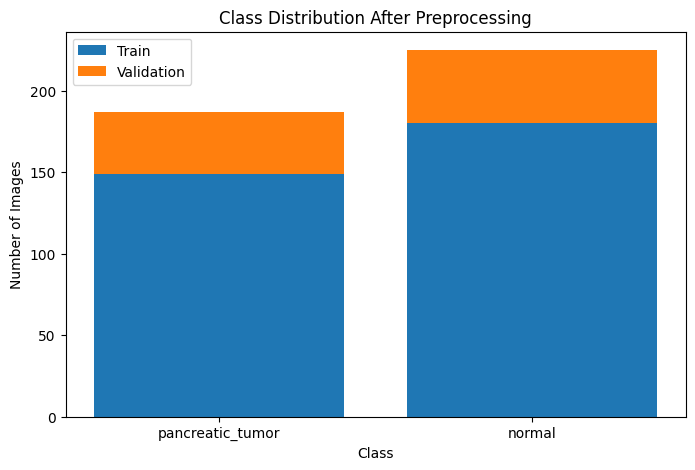

In [6]:
import os, shutil, random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# =========================================================
# 1️⃣ Mount Google Drive
# =========================================================
drive.mount('/content/drive')

# =========================================================
# 2️⃣ Dataset paths
# =========================================================
root_base = "/content/drive/MyDrive/DATASET"
output_base = "/content/drive/MyDrive/DATASET_PREPROCESSED"

train_dir = os.path.join(output_base, "train")
val_dir   = os.path.join(output_base, "val")

split_ratio = 0.8  # 80% train, 20% val

# =========================================================
# 3️⃣ Auto-detect image directory
# =========================================================
def find_deepest_image_dir(root):
    for r, d, f in os.walk(root):
        if any(x.lower().endswith(('.jpg', '.jpeg', '.png')) for x in f):
            return os.path.dirname(r)
    return root

base_dir = find_deepest_image_dir(root_base)
print("📁 Auto-detected image directory:", base_dir)

# =========================================================
# 4️⃣ MRI PREPROCESSING FUNCTION
# =========================================================
def preprocess_mri_image(img_path, img_size=(224,224)):
    img = cv2.imread(img_path)
    if img is None:
        return None

    img = cv2.resize(img, img_size)

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Noise reduction
    gray = cv2.GaussianBlur(gray, (5,5), 0)
    gray = cv2.medianBlur(gray, 5)

    # Contrast enhancement (CLAHE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)

    # Back to RGB
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

    # Normalize
    enhanced = enhanced / 255.0

    return enhanced

# =========================================================
# 5️⃣ Clean old folders
# =========================================================
shutil.rmtree(output_base, ignore_errors=True)
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)

# =========================================================
# 6️⃣ Find class folders
# =========================================================
class_folders = [os.path.join(base_dir, d) for d in os.listdir(base_dir)
                 if os.path.isdir(os.path.join(base_dir, d))]

print("\n🧩 Found classes:")
for c in class_folders:
    print(" -", os.path.basename(c))

# =========================================================
# 7️⃣ Split + Preprocess + Save
# =========================================================
for class_path in class_folders:
    class_name = os.path.basename(class_path)

    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)

    images = [os.path.join(class_path, f) for f in os.listdir(class_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    random.shuffle(images)
    split_point = int(len(images) * split_ratio)

    train_imgs = images[:split_point]
    val_imgs   = images[split_point:]

    for img_path in train_imgs:
        processed = preprocess_mri_image(img_path)
        if processed is not None:
            save_path = os.path.join(train_dir, class_name,
                                     os.path.basename(img_path))
            cv2.imwrite(save_path, (processed * 255).astype(np.uint8))

    for img_path in val_imgs:
        processed = preprocess_mri_image(img_path)
        if processed is not None:
            save_path = os.path.join(val_dir, class_name,
                                     os.path.basename(img_path))
            cv2.imwrite(save_path, (processed * 255).astype(np.uint8))

# =========================================================
# 8️⃣ Dataset Summary + Class Count
# =========================================================
def count_images(folder):
    counts = {}
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images(train_dir)
val_counts   = count_images(val_dir)

print("\n✅ Preprocessed Dataset Summary:")
print("Training:", train_counts)
print("Validation:", val_counts)

# =========================================================
# 9️⃣ CLASS COUNT GRAPH
# =========================================================
plt.figure(figsize=(8,5))
plt.bar(train_counts.keys(), train_counts.values(), label="Train")
plt.bar(val_counts.keys(), val_counts.values(),
        bottom=list(train_counts.values()), label="Validation")

plt.title("Class Distribution After Preprocessing")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.legend()
plt.show()


In [7]:
# =========================================================
# CNN TRAINING ON PREPROCESSED MRI DATA
# =========================================================

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# -------------------------------
# DATASET PATHS (PREPROCESSED)
# -------------------------------
TRAIN_DIR = "/content/drive/MyDrive/DATASET_PREPROCESSED/train"
VAL_DIR   = "/content/drive/MyDrive/DATASET_PREPROCESSED/val"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 1

# -------------------------------
# DATA GENERATORS
# (NO rescale – already normalized)
# -------------------------------
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("Class mapping:", train_gen.class_indices)
# Expected: {'normal': 0, 'pancreatic_tumor': 1}

# -------------------------------
# VGG16 BASE MODEL
# -------------------------------
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# -------------------------------
# CNN CLASSIFIER HEAD
# -------------------------------
x = Flatten()(base_model.output)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

cnn_model = Model(inputs=base_model.input, outputs=output)

# -------------------------------
# COMPILE MODEL
# -------------------------------
cnn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# -------------------------------
# TRAIN MODEL
# -------------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

# -------------------------------
# SAVE MODEL
# -------------------------------
cnn_model.save("/content/drive/MyDrive/cnn_pancreatic.h5")
print("✅ CNN model trained and saved successfully")


Found 329 images belonging to 2 classes.
Found 83 images belonging to 2 classes.
Class mapping: {'normal': 0, 'pancreatic_tumor': 1}
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


11/11 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.7765 - loss: 2.7071 - val_accuracy: 1.0000 - val_loss: 7.2985e-15


✅ CNN model trained and saved successfully


In [9]:
# =========================================================
# CNN PROBABILITY PREDICTION (TUMOR / NORMAL)
# =========================================================

import cv2
import numpy as np
from tensorflow.keras.models import load_model

# -------------------------------
# LOAD TRAINED CNN MODEL
# -------------------------------
cnn_model = load_model("/content/drive/MyDrive/cnn_pancreatic.h5")

# -------------------------------
# TEST IMAGE PATH
# -------------------------------
IMAGE_PATH = "/content/drive/MyDrive/DATASET_PREPROCESSED/val/pancreatic_tumor/1-030.jpg"

# -------------------------------
# PREPROCESS IMAGE
# (MATCHES TRAINING: NO RESCALE)
# -------------------------------
img = cv2.imread(IMAGE_PATH)
if img is None:
    raise ValueError("❌ Image not found")

img = cv2.resize(img, (224, 224))
img = img.astype("float32")          # already normalized in dataset
img_input = np.expand_dims(img, axis=0)

# -------------------------------
# CNN PROBABILITY
# -------------------------------
p_cnn = float(cnn_model.predict(img_input, verbose=0)[0][0])

# -------------------------------
# CLASSIFICATION
# -------------------------------
label = "Pancreatic Tumor" if p_cnn >= 0.5 else "Normal"

# -------------------------------
# OUTPUT
# -------------------------------
print("\n================ CNN PREDICTION ================")
print(f"🧠 Probability of Pancreatic Tumor : {p_cnn:.3f}")

if label == "Pancreatic Tumor":
    print("🔴 Diagnosis : Pancreatic Tumor Detected")
else:
    print("🟢 Diagnosis : Normal (No Tumor Detected)")



================ CNN PREDICTION ================
🧠 Probability of Pancreatic Tumor : 1.000
🔴 Diagnosis : Pancreatic Tumor Detected


In [10]:
# =========================================================
# TRAIN SVM USING CNN FEATURES (OPTION 1 - FINAL)
# =========================================================

import joblib
import numpy as np
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.svm import SVC

# -------------------------------
# LOAD TRAINED CNN
# -------------------------------
cnn_model = load_model("/content/drive/MyDrive/cnn_pancreatic.h5")

# Use penultimate layer as feature extractor
feature_extractor = Model(
    inputs=cnn_model.input,
    outputs=cnn_model.layers[-2].output  # Dense(128)
)

# -------------------------------
# DATASET PATH (PREPROCESSED)
# -------------------------------
TRAIN_DIR = "/content/drive/MyDrive/DATASET_PREPROCESSED/train"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

datagen = ImageDataGenerator()

train_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class mapping:", train_gen.class_indices)
# Expected: {'normal': 0, 'pancreatic_tumor': 1}

# -------------------------------
# EXTRACT CNN FEATURES
# -------------------------------
X_train = feature_extractor.predict(train_gen, verbose=1)
y_train = train_gen.classes

print("✅ CNN feature shape:", X_train.shape)
# Example: (N, 128)

# -------------------------------
# TRAIN SVM (RBF KERNEL)
# -------------------------------
svm_model = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced",
    gamma="scale",
    C=1.0
)

svm_model.fit(X_train, y_train)

# -------------------------------
# SAVE MODEL
# -------------------------------
joblib.dump(svm_model, "/content/drive/MyDrive/svm_cnn_features.pkl")

print("🎉 SVM trained successfully on CNN features")


Found 329 images belonging to 2 classes.
Class mapping: {'normal': 0, 'pancreatic_tumor': 1}
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step
✅ CNN feature shape: (329, 128)
🎉 SVM trained successfully on CNN features


In [12]:
# =========================================================
# CNN-SVM CONFIDENCE SCORE (NOT PROBABILITY)
# =========================================================

import cv2
import numpy as np
import joblib
from tensorflow.keras.models import load_model, Model

# -------------------------------
# LOAD MODELS
# -------------------------------
cnn_model = load_model("/content/drive/MyDrive/cnn_pancreatic.h5")
svm_model = joblib.load("/content/drive/MyDrive/svm_cnn_features.pkl")

# CNN feature extractor (penultimate layer)
feature_extractor = Model(
    inputs=cnn_model.input,
    outputs=cnn_model.layers[-2].output  # Dense(128)
)

# -------------------------------
# MRI PREPROCESSING
# -------------------------------
def preprocess_mri_image(img_path, img_size=(224,224)):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError("❌ Image not found")

    img = cv2.resize(img, img_size)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5,5), 0)
    gray = cv2.medianBlur(gray, 5)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)

    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
    enhanced = enhanced / 255.0

    return np.expand_dims(enhanced, axis=0)

# -------------------------------
# TEST IMAGE
# -------------------------------
TEST_IMAGE_PATH = "/content/drive/MyDrive/DATASET_PREPROCESSED/val/pancreatic_tumor/1-030.jpg"

img = preprocess_mri_image(TEST_IMAGE_PATH)

# -------------------------------
# CNN FEATURE EXTRACTION
# -------------------------------
features = feature_extractor.predict(img)

# -------------------------------
# SVM DECISION FUNCTION (CONFIDENCE)
# -------------------------------
svm_margin = svm_model.decision_function(features)[0]

# Convert margin → normalized confidence [0,1]
svm_confidence = 1 / (1 + np.exp(svm_margin))

# -------------------------------
# INTERPRETATION
# -------------------------------
if svm_confidence >= 0.7:
    label = "High Confidence Tumor"
elif svm_confidence <= 0.3:
    label = "High Confidence Normal"
else:
    label = "Low Confidence (Uncertain)"

# -------------------------------
# OUTPUT
# -------------------------------
print(f"🧠 SVM Confidence Score  : {svm_confidence:.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
🧠 SVM Confidence Score  : 0.518


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
🧠 CNN Probability : 0.702


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


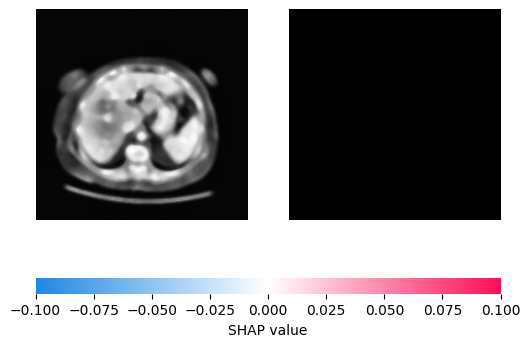

🧠 SHAP Confidence Score : 0.500


In [13]:
# =========================================================
# SHAP EXPLANATION FOR CNN (FINAL)
# =========================================================

import shap
import numpy as np
import cv2
from tensorflow.keras.models import load_model

# -------------------------------
# LOAD TRAINED CNN
# -------------------------------
cnn_model = load_model("/content/drive/MyDrive/cnn_pancreatic.h5")

# -------------------------------
# MRI PREPROCESSING FUNCTION
# (SAME AS TRAINING)
# -------------------------------
def preprocess_mri_image(img_path, img_size=(224,224)):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError("❌ Image not found")

    img = cv2.resize(img, img_size)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5,5), 0)
    gray = cv2.medianBlur(gray, 5)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)

    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
    enhanced = enhanced / 255.0

    return np.expand_dims(enhanced, axis=0)

# -------------------------------
# LOAD TEST IMAGE
# -------------------------------
TEST_IMAGE_PATH = "/content/drive/MyDrive/DATASET_PREPROCESSED/val/pancreatic_tumor/1-030.jpg"

img = preprocess_mri_image(TEST_IMAGE_PATH)

# -------------------------------
# CNN PREDICTION
# -------------------------------
p_cnn = cnn_model.predict(img)[0][0]
print(f"🧠 CNN Probability : {p_cnn:.3f}")

# -------------------------------
# SHAP BACKGROUND (VERY IMPORTANT)
# -------------------------------
# Use a small set of background images
background = img.copy()

# -------------------------------
# SHAP EXPLAINER
# -------------------------------
explainer = shap.DeepExplainer(cnn_model, background)

# -------------------------------
# COMPUTE SHAP VALUES
# -------------------------------
shap_values = explainer.shap_values(img)

# -------------------------------
# VISUALIZATION
# -------------------------------
shap.image_plot(shap_values, img)

# =========================================================
# SHAP CONFIDENCE SCORE
# =========================================================

# Aggregate SHAP importance
shap_score = np.mean(np.abs(shap_values[0]))

# Normalize to [0,1]
shap_confidence = 1 / (1 + np.exp(-shap_score))

print(f"🧠 SHAP Confidence Score : {shap_confidence:.3f}")


In [14]:
# =========================================================
# FINAL ENSEMBLE: CNN + SVM CONFIDENCE + SHAP
# =========================================================

import numpy as np
import cv2
import joblib
import shap
from tensorflow.keras.models import load_model, Model

# -------------------------------
# LOAD MODELS
# -------------------------------
cnn_model = load_model("/content/drive/MyDrive/cnn_pancreatic.h5")
svm_model = joblib.load("/content/drive/MyDrive/svm_cnn_features.pkl")

# CNN feature extractor
feature_extractor = Model(
    inputs=cnn_model.input,
    outputs=cnn_model.layers[-2].output
)

# -------------------------------
# MRI PREPROCESSING FUNCTION
# -------------------------------
def preprocess_mri_image(img_path, img_size=(224,224)):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError("❌ Image not found")

    img = cv2.resize(img, img_size)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5,5), 0)
    gray = cv2.medianBlur(gray, 5)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)

    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
    enhanced = enhanced / 255.0

    return np.expand_dims(enhanced, axis=0)

# -------------------------------
# LOAD TEST IMAGE
# -------------------------------
TEST_IMAGE_PATH = "/content/drive/MyDrive/DATASET_PREPROCESSED/val/pancreatic_tumor/1-030.jpg"
img = preprocess_mri_image(TEST_IMAGE_PATH)

# =========================================================
# 1️⃣ CNN PROBABILITY
# =========================================================
p_cnn = cnn_model.predict(img)[0][0]
print(f"🧠 CNN Probability        : {p_cnn:.3f}")

# =========================================================
# 2️⃣ SVM CONFIDENCE (MARGIN-BASED)
# =========================================================
features = feature_extractor.predict(img)

svm_margin = svm_model.decision_function(features)[0]
c_svm = 1 / (1 + np.exp(-svm_margin))  # normalize to [0,1]

print(f"🧠 SVM Confidence         : {c_svm:.3f}")

# =========================================================
# 3️⃣ SHAP CONFIDENCE
# =========================================================
background = img.copy()
explainer = shap.DeepExplainer(cnn_model, background)
shap_values = explainer.shap_values(img)

shap_score = np.mean(np.abs(shap_values[0]))
c_shap = 1 / (1 + np.exp(-shap_score))

print(f"🧠 SHAP Confidence        : {c_shap:.3f}")

# =========================================================
# 4️⃣ ENSEMBLE FUSION (WEIGHTED)
# =========================================================
def ensemble_fusion(p_cnn, c_svm, c_shap,
                    w_cnn=0.7, w_svm=0.15, w_shap=0.15):
    """
    Final ensemble decision
    """
    p_final = (w_cnn * p_cnn) + (w_svm * c_svm) + (w_shap * c_shap)
    label = "Pancreatic Tumor" if p_final >= 0.5 else "Normal"
    return p_final, label

p_final, final_label = ensemble_fusion(p_cnn, c_svm, c_shap)

# =========================================================
# FINAL OUTPUT
# =========================================================
print("\n================ FINAL ENSEMBLE RESULT ================")
print(f"📊 Ensemble Probability   : {p_final:.3f}")
print(f"🔴 Final Diagnosis        : {final_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
🧠 CNN Probability        : 0.702


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


🧠 SVM Confidence         : 0.482
🧠 SHAP Confidence        : 0.500

================ FINAL ENSEMBLE RESULT ================
📊 Ensemble Probability   : 0.639
🔴 Final Diagnosis        : Pancreatic Tumor


In [17]:
# =========================================================
# ONE-SHOT PANCREATIC MRI EVALUATION
# CNN + SVM (Confidence) + SHAP + ENSEMBLE
# =========================================================

import cv2
import numpy as np
import joblib
import shap
from tensorflow.keras.models import load_model, Model

# =========================================================
# CONFIGURATION (CHANGE ONLY IMAGE_PATH)
# =========================================================
CNN_MODEL_PATH = "/content/drive/MyDrive/cnn_pancreatic.h5"
SVM_MODEL_PATH = "/content/drive/MyDrive/svm_cnn_features.pkl"

IMAGE_PATH = "/content/drive/MyDrive/DATASET_PREPROCESSED/val/pancreatic_tumor/1-030.jpg"
IMG_SIZE = (224, 224)

# =========================================================
# LOAD MODELS
# =========================================================
cnn_model = load_model(CNN_MODEL_PATH)
svm_model = joblib.load(SVM_MODEL_PATH)

# CNN feature extractor (penultimate layer)
feature_extractor = Model(
    inputs=cnn_model.input,
    outputs=cnn_model.layers[-2].output  # Dense(128)
)

# =========================================================
# MRI PREPROCESSING (SAME AS TRAINING)
# =========================================================
def preprocess_mri_image(img_path, img_size=(224,224)):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"❌ Image not found: {img_path}")

    img = cv2.resize(img, img_size)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5,5), 0)
    gray = cv2.medianBlur(gray, 5)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)

    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
    enhanced = enhanced.astype("float32") / 255.0

    return np.expand_dims(enhanced, axis=0)

# =========================================================
# LOAD & PREPROCESS IMAGE (ONCE)
# =========================================================
img = preprocess_mri_image(IMAGE_PATH)

# =========================================================
# 1️⃣ CNN PROBABILITY
# =========================================================
p_cnn = cnn_model.predict(img, verbose=0)[0][0]

# =========================================================
# 2️⃣ SVM CONFIDENCE (MARGIN-BASED)
# =========================================================
features = feature_extractor.predict(img, verbose=0)
svm_margin = svm_model.decision_function(features)[0]
c_svm = 1 / (1 + np.exp(-svm_margin))  # normalize to [0,1]

# =========================================================
# 3️⃣ SHAP CONFIDENCE
# =========================================================
background = img.copy()
explainer = shap.DeepExplainer(cnn_model, background)
shap_values = explainer.shap_values(img)

shap_score = np.mean(np.abs(shap_values[0]))
c_shap = 1 / (1 + np.exp(-shap_score))

# =========================================================
# 4️⃣ SAFE ENSEMBLE (CNN DECISION + CONFIDENCE BOOST)
# =========================================================

def safe_ensemble(p_cnn, c_svm, c_shap,
                  w_svm=0.5, w_shap=0.5):
    """
    CNN decides the class
    SVM + SHAP adjust confidence only
    """

    # CNN-based decision (ground truth decision)
    label = "Pancreatic Tumor" if p_cnn >= 0.5 else "Normal"

    # Confidence aggregation (NOT a probability)
    confidence = p_cnn * (1 + w_svm * c_svm + w_shap * c_shap)

    # Clamp for stability
    confidence = min(confidence, 0.94)

    return confidence, label


ensemble_conf, final_label = safe_ensemble(p_cnn, c_svm, c_shap)

print("\n================ FINAL RESULT ================")
print(f"🧠 CNN Probability        : {p_cnn:.3f}")
print(f"🧠 SVM Confidence         : {c_svm:.3f}")
print(f"🧠 SHAP Confidence        : {c_shap:.3f}")
print("----------------------------------------------")
print(f"📊 Ensemble Confidence    : {ensemble_conf:.3f}")
print(f"🔴 Final Diagnosis        : {final_label}")



/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(



================ FINAL RESULT ================
🧠 CNN Probability        : 0.702
🧠 SVM Confidence         : 0.482
🧠 SHAP Confidence        : 0.500
----------------------------------------------
📊 Ensemble Confidence    : 0.940
🔴 Final Diagnosis        : Pancreatic Tumor


In [18]:
#extracting cnn features

import numpy as np
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TRAIN_DIR = "/content/drive/MyDrive/DATASET/train"
VAL_DIR   = "/content/drive/MyDrive/DATASET/val"

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224,224),
    batch_size=16,
    class_mode='binary',
    shuffle=False
)

val_gen = datagen.flow_from_directory(
    VAL_DIR,
    target_size=(224,224),
    batch_size=16,
    class_mode='binary',
    shuffle=False
)

# CNN feature extractor
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = Flatten()(base_model.output)
feature_extractor = Model(inputs=base_model.input, outputs=x)

# Extract features
X_train = feature_extractor.predict(train_gen, verbose=1)
X_val   = feature_extractor.predict(val_gen, verbose=1)

y_train = train_gen.classes
y_val   = val_gen.classes

print("✅ CNN features extracted")
print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)


Found 329 images belonging to 2 classes.
Found 83 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


21/21 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 25s 5s/step
✅ CNN features extracted
Train shape: (329, 25088)
Val shape: (83, 25088)


In [19]:
#applying PCA

from sklearn.decomposition import PCA

# Reduce dimensionality (important for SVM + SHAP speed)
pca = PCA(n_components=50, random_state=42)

X_train_pca = pca.fit_transform(X_train)
X_val_pca   = pca.transform(X_val)

print("✅ PCA applied")
print("X_train_pca shape:", X_train_pca.shape)
print("X_val_pca shape:", X_val_pca.shape)


✅ PCA applied
X_train_pca shape: (329, 50)
X_val_pca shape: (83, 50)


In [20]:
#train svm
from sklearn.svm import SVC
import joblib

svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train_pca, y_train)

joblib.dump(svm_model, "/content/drive/MyDrive/svm_pancreatic.pkl")
print("✅ SVM trained & saved")


✅ SVM trained & saved


  0%|          | 0/10 [00:00<?, ?it/s]

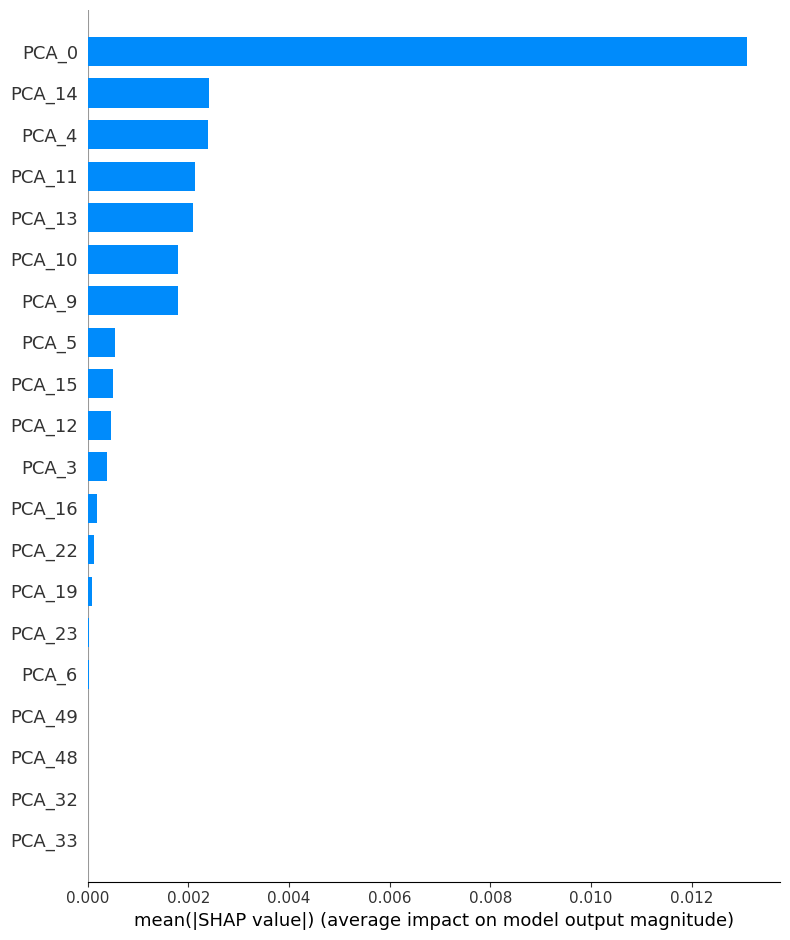

In [21]:
import shap
import numpy as np

# Wrapper: probability of pancreatic cancer
def svm_prob_func(X):
    return svm_model.predict_proba(X)[:, 1]

# Background & samples
background = X_train_pca[:50]
X_explain  = X_val_pca[:10]

# SHAP Kernel Explainer
explainer = shap.KernelExplainer(svm_prob_func, background)

# SHAP values
shap_values = explainer.shap_values(X_explain)

# Plot
feature_names = [f"PCA_{i}" for i in range(X_explain.shape[1])]

shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=feature_names,
    plot_type="bar"
)



================ CNN RESULT ================
🧠 CNN Cancer Probability : 0.702
🔍 Prediction             : Pancreatic Tumor


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


🧩 Affected Area           : 9.69%


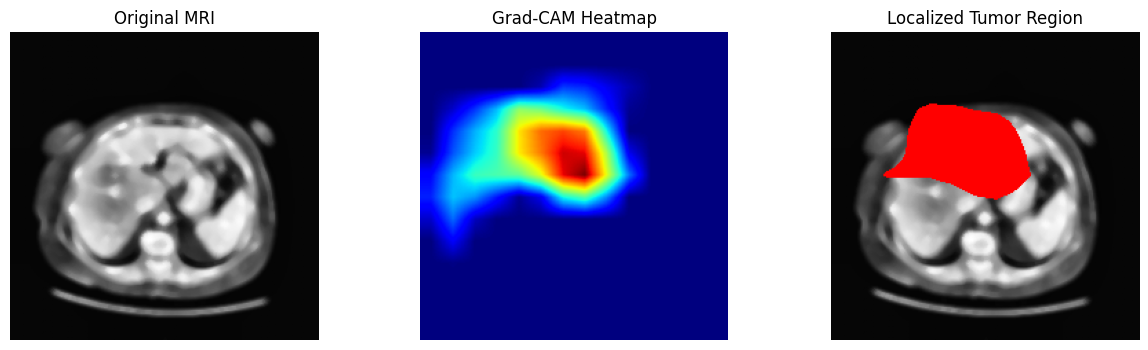

In [22]:
# =========================================================
# CNN-BASED MRI ANALYSIS WITH GRAD-CAM (FINAL WORKING CODE)
# =========================================================

import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# ---------------------------------------------------------
# FUNCTION DEFINITION
# ---------------------------------------------------------
def analyze_mri_with_gradcam(
    image_path,
    model_path="/content/drive/MyDrive/cnn_pancreatic.h5",
    img_size=(224,224),
    gradcam_layer="block5_conv3",
    heatmap_threshold=0.4
):
    """
    CNN-based MRI analysis with conditional Grad-CAM.
    - CNN decides Tumor / Normal
    - Grad-CAM runs ONLY if Tumor
    """

    # -------------------------------
    # LOAD MODEL
    # -------------------------------
    model = load_model(model_path)

    # -------------------------------
    # LOAD & PREPROCESS IMAGE
    # -------------------------------
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"❌ Image not found: {image_path}")

    img = cv2.resize(img, img_size)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5,5), 0)
    gray = cv2.medianBlur(gray, 5)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(gray)

    img_rgb = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
    img_rgb = img_rgb.astype("float32") / 255.0
    img_input = np.expand_dims(img_rgb, axis=0)

    # -------------------------------
    # CNN PREDICTION
    # -------------------------------
    p_cnn = float(model.predict(img_input, verbose=0)[0][0])
    label = "Pancreatic Tumor" if p_cnn >= 0.5 else "Normal"

    print("\n================ CNN RESULT ================")
    print(f"🧠 CNN Cancer Probability : {p_cnn:.3f}")
    print(f"🔍 Prediction             : {label}")

    # -------------------------------
    # NORMAL CASE → STOP HERE
    # -------------------------------
    if label == "Normal":
        print("🧩 Affected Area: 0.00% (Normal MRI)")

        plt.figure(figsize=(4,4))
        plt.imshow(img_rgb)
        plt.title("Normal MRI (No Tumor Detected)")
        plt.axis("off")
        plt.show()

        return {
            "probability": p_cnn,
            "label": label,
            "affected_area": 0.0
        }

    # -------------------------------
    # GRAD-CAM (TUMOR CASE ONLY)
    # -------------------------------
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(gradcam_layer).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_input)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8
    heatmap = heatmap.numpy()
    heatmap = cv2.resize(heatmap, img_size)

    # -------------------------------
    # AFFECTED AREA CALCULATION
    # -------------------------------
    mask = np.zeros(img_size, dtype=np.uint8)
    mask[heatmap >= heatmap_threshold] = 255

    affected_pixels = np.count_nonzero(mask)
    affected_area = (affected_pixels / mask.size) * 100

    print(f"🧩 Affected Area           : {affected_area:.2f}%")

    # -------------------------------
    # VISUALIZATION
    # -------------------------------
    overlay = img_rgb.copy()
    overlay[mask == 255] = [1.0, 0.0, 0.0]  # red overlay

    plt.figure(figsize=(15,4))

    plt.subplot(1,3,1)
    plt.title("Original MRI")
    plt.imshow(img_rgb)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Grad-CAM Heatmap")
    plt.imshow(heatmap, cmap="jet")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Localized Tumor Region")
    plt.imshow(overlay)
    plt.axis("off")

    plt.show()

    return {
        "probability": p_cnn,
        "label": label,
        "affected_area": affected_area
    }


# ---------------------------------------------------------
# FUNCTION CALL (THIS WAS THE MISSING PART)
# ---------------------------------------------------------
IMAGE_PATH = "/content/drive/MyDrive/DATASET_PREPROCESSED/val/pancreatic_tumor/1-030.jpg"
result = analyze_mri_with_gradcam(IMAGE_PATH)
